In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% ! important;}
div.cell.code_cell.rendered{width:100%}
div.input_prompt{padding:0px}
div.CodeMirror {font-family:Consolas ; font-size:12pt;}
div.text_cell_render.rendered_html {font-size:12pt;}
div.output {font-size:12pt; font-weight:bold}
div.input {font-family:Consolas ; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper {padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
</style>
"""))

# 데이터셋을 라이브러리에서 가져올 예정. 파일에서도 봄

In [1]:
import numpy as np
import pandas as pd
from tensorflow.keras.datasets import mnist # mnist 훈련 셋과 테스트 셋
from tensorflow.keras.utils import to_categorical # 원핫인코딩
from tensorflow.keras.models import Sequential, save_model, load_model
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.layers import LeakyReLU, ELU, ReLU
from matplotlib import pyplot as plt # 학습과정 시각화
# scale 조정, train_test_split 등을 추가

In [4]:
data = np.loadtxt('data/mnist_train_small.csv', delimiter=',', skiprows=1)
data.shape

(100, 785)

In [8]:
print('타겟 :', data[1,0])
# print('이미지 :', data[1,1:].reshape(28,28))
image = data[1,1:].reshape(28,28)
image.shape

타겟 : 0.0


(28, 28)

In [9]:
for row in image:
    for pixel in row:
        print("{:3.0f}".format(pixel), end='')
    print()

  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0 51159253159 50  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0  0 48238252252252237  0  0  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0  0  0 54227253252239233252 57  6  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0 10 60224252253252202 84252253122  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0  0163252252252253252252 96189253167  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0  0 51238253253190114253228 47 79255168  0  0  0  0  0  0
  0  0  0  0  0  0  0  0  0 48238252252179 12 75121 21  0  0253243 50  0  0  0  0  0
  0  0  0  0  0  0  0  0 38165253233208 84  0  0  0  0  0  025325

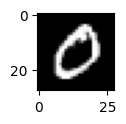

In [11]:
plt.figure(figsize=(1,1))
plt.imshow(image,cmap='gray')

In [ ]:
# 칼라사진 -> 흑백모드로 넘파이 배열로 읽기

In [12]:
%pip install opencv-python==4.8.1.78

   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.7/38.1 MB 35.7 MB/s eta 0:00:01
   ------------- -------------------------- 12.6/38.1 MB 43.8 MB/s eta 0:00:01
   ------------- -------------------------- 12.6/38.1 MB 43.8 MB/s eta 0:00:01
   ---------------------- ----------------- 21.5/38.1 MB 28.9 MB/s eta 0:00:01
   ---------------------------------- ----- 32.5/38.1 MB 34.4 MB/s eta 0:00:01
   ------------------------------------- -- 35.7/38.1 MB 34.9 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 29.9 MB/s  0:00:01
Note: you may need to restart the kernel to use updated packages.


In [15]:
import cv2
# 사진 이미지를 흑백포맷으로 넘파이 배열로 읽어오기
image_gray = cv2.imread('c:/ai/letNote/05_DeepLearning/sample.jpg', cv2.IMREAD_GRAYSCALE)
image_gray.shape

(408, 612)

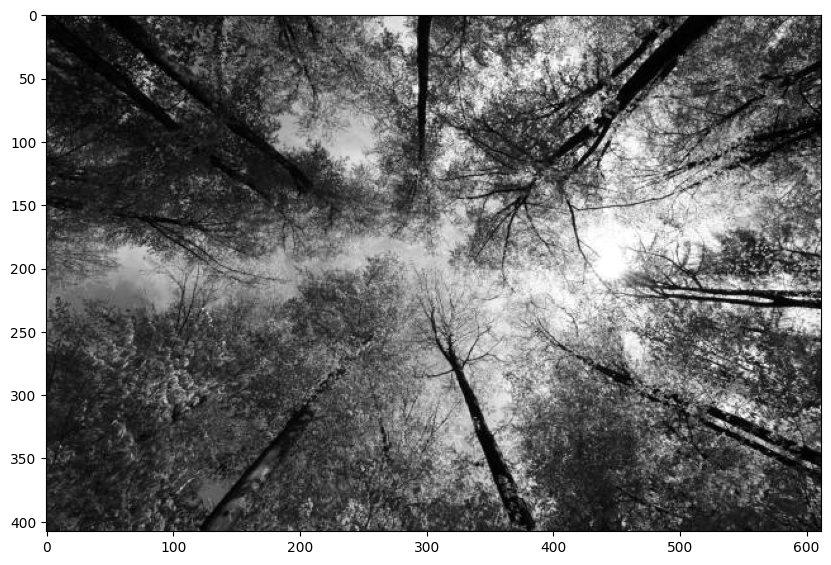

In [16]:
plt.figure(figsize=(10,10))
plt.imshow(image_gray,cmap='gray')

# 1. 데이터 생성 및 전처리

In [30]:
(X_train, y_train), (X_test,y_test) = mnist.load_data()
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

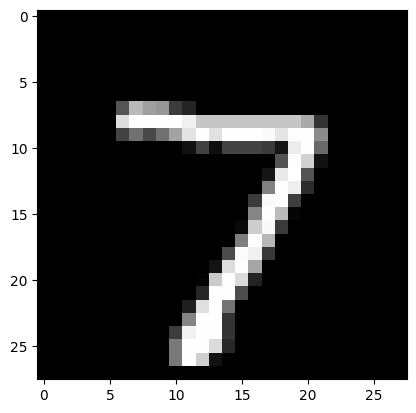

In [22]:
plt.imshow(X_test[0], cmap='gray')
plt.show()
# for row in X_test[0]:
#     for pixel in row:
#         print('{:3.0f}'.format(pixel), end=' ')
#     print()

In [31]:
# train 데이터 6만개 => train(5만개) + val(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

In [24]:
print('학습셋 :', X_train.shape, y_train.shape)
print('검증셋 :', X_val.shape, y_val.shape)
print('시험셋 :', X_test.shape, y_test.shape)

학습셋 : (50000, 28, 28) (50000,)
검증셋 : (10000, 28, 28) (10000,)
시험셋 : (10000, 28, 28) (10000,)


In [32]:
# 입력(독립)변수 (n, 28, 28) -> (n, 28*28)
X_train.reshape(50000,28*28)

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [35]:
# 입력(독립)변수 (n, 28, 28) -> (n, 28*28) -> 실수형변환 -> 스케일조정(/255.0)
train_X = X_train.reshape(50000,28*28).astype('float32')/255.0
val_X = X_val.reshape(-1,784).astype('float32')/255.0
test_X = X_test.reshape(10000,-1).astype('float32')/255.0
train_X.shape, val_X.shape, test_X.shape

((50000, 784), (10000, 784), (10000, 784))

In [39]:
#분류분석을 위한 타겟변수의 원핫인코딩
# print(y_train[0])
# to_categorical(y_train)[0]
train_Y = to_categorical(y_train, 10) # 10:카테고리수(안쓰면 자동 입력)
val_Y = to_categorical(y_val)
test_Y= to_categorical(y_test)
train_Y.shape, val_Y.shape, test_Y.shape

((50000, 10), (10000, 10), (10000, 10))

In [44]:
# train 5만 -> 700개, val 1만 -> 300개 (목적 : 수업시간 중 fit 시간 절약)
train_idx = np.random.choice(50000,700) # 0부터 50000 미만의 수 700개 뽑기 비복원추출
val_idx   = np.random.choice(10000,300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X = val_X[val_idx]
val_Y = val_Y[val_idx]

In [47]:
train_X.shape, train_Y.shape, val_X.shape, val_Y.shape

((700, 784), (700, 10), (300, 784), (300, 10))

# 2. 모델 구성

In [48]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2)) # activation = 'leakeyrelu' 사용 불가
model.add(LeakyReLU(alpha=0.01)) # 음수결과에 대해 1%만 통과
model.add(Dense(units=10, activation='softmax'))
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 2)                 1570      
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 2)                 0         
                                                                 
 dense_1 (Dense)             (None, 10)                30        
                                                                 
Total params: 1,600
Trainable params: 1,600
Non-trainable params: 0
_________________________________________________________________


# 3. 힉습과정 설정

In [51]:
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy(원핫인코딩 자동으로)
              optimizer='adam',
              metrics=['accuracy'] # 평가지표
             )

# 4. 모델 학습

In [52]:
%%time
hist = model.fit(train_X, train_Y, # 학습셋
                epochs=200,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1)

Epoch 1/200
7/7 [==============================] - 0s 26ms/step - loss: 2.3045 - accuracy: 0.1157 - val_loss: 2.2696 - val_accuracy: 0.1333
Epoch 2/200
7/7 [==============================] - 0s 5ms/step - loss: 2.2659 - accuracy: 0.1229 - val_loss: 2.2434 - val_accuracy: 0.1733
Epoch 3/200
7/7 [==============================] - 0s 3ms/step - loss: 2.2423 - accuracy: 0.1643 - val_loss: 2.2211 - val_accuracy: 0.1767
Epoch 4/200
7/7 [==============================] - 0s 3ms/step - loss: 2.2197 - accuracy: 0.1843 - val_loss: 2.2014 - val_accuracy: 0.1900
Epoch 5/200
7/7 [==============================] - 0s 3ms/step - loss: 2.1981 - accuracy: 0.1914 - val_loss: 2.1844 - val_accuracy: 0.1733
Epoch 6/200
7/7 [==============================] - 0s 3ms/step - loss: 2.1770 - accuracy: 0.1914 - val_loss: 2.1693 - val_accuracy: 0.1833
Epoch 7/200
7/7 [==============================] - 0s 3ms/step - loss: 2.1564 - accuracy: 0.2057 - val_loss: 2.1558 - val_accuracy: 0.1967
Epoch 8/200
7/7 [=========

7/7 [==============================] - 0s 5ms/step - loss: 1.3774 - accuracy: 0.5200 - val_loss: 1.5228 - val_accuracy: 0.4400
Epoch 118/200
7/7 [==============================] - 0s 3ms/step - loss: 1.3743 - accuracy: 0.5229 - val_loss: 1.5214 - val_accuracy: 0.4400
Epoch 119/200
7/7 [==============================] - 0s 3ms/step - loss: 1.3711 - accuracy: 0.5257 - val_loss: 1.5174 - val_accuracy: 0.4433
Epoch 120/200
7/7 [==============================] - 0s 3ms/step - loss: 1.3684 - accuracy: 0.5271 - val_loss: 1.5156 - val_accuracy: 0.4500
Epoch 121/200
7/7 [==============================] - 0s 3ms/step - loss: 1.3647 - accuracy: 0.5243 - val_loss: 1.5185 - val_accuracy: 0.4333
Epoch 122/200
7/7 [==============================] - 0s 6ms/step - loss: 1.3619 - accuracy: 0.5243 - val_loss: 1.5127 - val_accuracy: 0.4500
Epoch 123/200
7/7 [==============================] - 0s 6ms/step - loss: 1.3587 - accuracy: 0.5300 - val_loss: 1.5088 - val_accuracy: 0.4533
Epoch 124/200
7/7 [========

# 5. 모델 평가하기

In [53]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

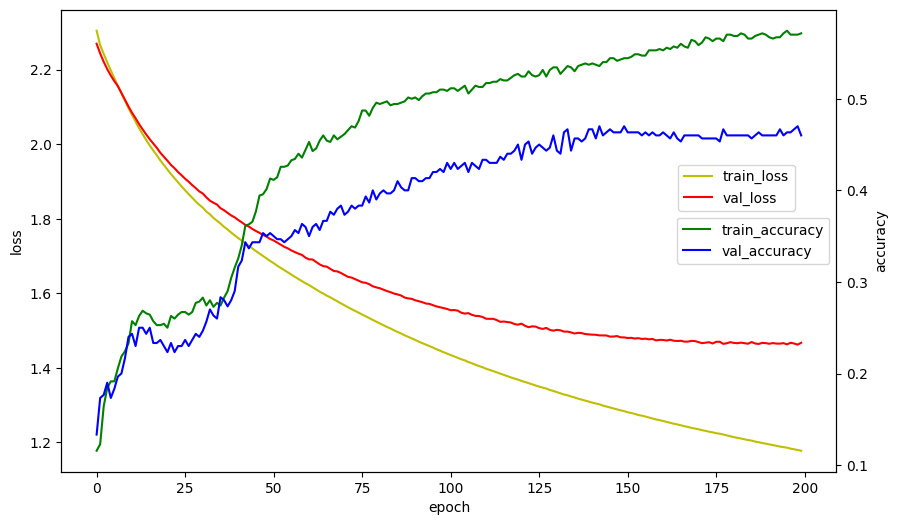

In [54]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [56]:
# 모델 평가(테스트셋)
loss_metrics = model.evaluate(test_X,test_Y, batch_size=100, verbose=0)
print('loss :', loss_metrics[0])
print('accuracy :', loss_metrics[1])

loss : 1.5174007415771484
accuracy : 0.45239999890327454


# 🤣 위 모델(DNN)의  accuracy 늘리기
- 데이터 확보
- 모델 수정(레이어 추가, units수 증가)
- 과적합 방지(validation data 추가, 활성화 함수 relu계열, tanh, dropout)
- epochs 조정 (증가세 : epochs값 증량, 보합세, 감소세 : epochs값 감량)
- optimizer 변경

In [79]:
%%time
(X_train, y_train), (X_test,y_test) = mnist.load_data()

X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]

train_X = X_train.reshape(50000,28*28).astype('float32')/255.0
val_X = X_val.reshape(-1,784).astype('float32')/255.0
test_X = X_test.reshape(10000,-1).astype('float32')/255.0

train_Y = to_categorical(y_train, 10) # 10:카테고리수(안쓰면 자동 입력)
val_Y = to_categorical(y_val)
test_Y= to_categorical(y_test)

model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=512)) # activation = 'leakeyrelu' 사용 불가
model.add(LeakyReLU(alpha=0.01)) # 음수결과에 대해 1%만 통과
model.add(Dropout(0.2))
model.add(Dense(units=256))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))
model.add(Dense(units=128))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))
model.add(Dense(units=64))
model.add(LeakyReLU(alpha=0.01))
model.add(Dropout(0.3))
model.add(Dense(units=10, activation='softmax'))
model.summary()

model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy(원핫인코딩 자동으로)
              optimizer='adam',
              metrics=['accuracy'] # 평가지표
             )

hist = model.fit(train_X, train_Y, # 학습셋
                epochs=20,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1)

Model: "sequential_9"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_28 (Dense)            (None, 512)               401920    
                                                                 
 leaky_re_lu_18 (LeakyReLU)  (None, 512)               0         
                                                                 
 dropout_17 (Dropout)        (None, 512)               0         
                                                                 
 dense_29 (Dense)            (None, 256)               131328    
                                                                 
 leaky_re_lu_19 (LeakyReLU)  (None, 256)               0         
                                                                 
 dropout_18 (Dropout)        (None, 256)               0         
                                                                 
 dense_30 (Dense)            (None, 128)              

In [95]:
score = model.evaluate(test_X,test_Y)
score[1]

313/313 [==============================] - 1s 2ms/step - loss: 0.0909 - accuracy: 0.9825


0.9825000166893005

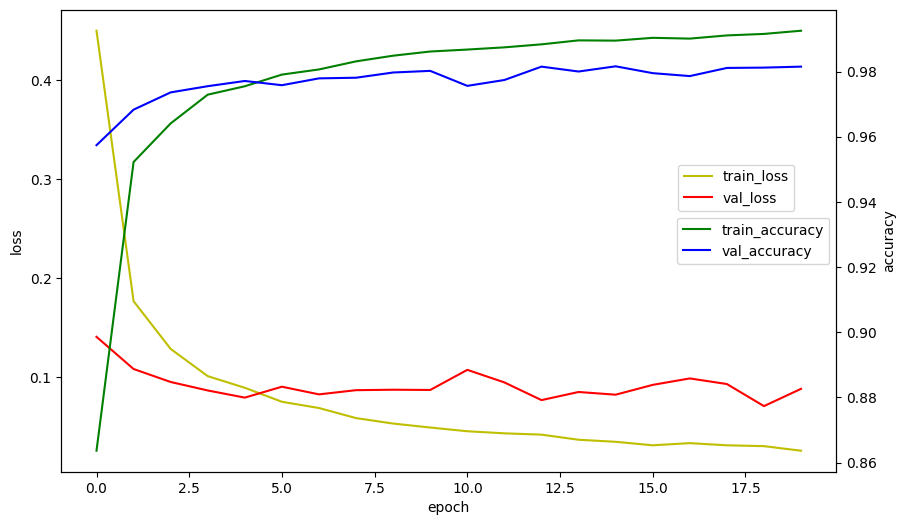

In [81]:
fig, loss_ax = plt.subplots(figsize=(10,6))
loss_ax.plot(hist.history['loss'],'y',label='train_loss')
loss_ax.plot(hist.history['val_loss'],'r',label='val_loss')
acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax 생성
acc_ax.plot(hist.history['accuracy'],'g',label='train_accuracy')
acc_ax.plot(hist.history['val_accuracy'],'b',label='val_accuracy')
loss_ax.set_xlabel('epoch')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')
loss_ax.legend(bbox_to_anchor=(0.955,0.68))
acc_ax.legend(loc= 'center right')
plt.show()

In [87]:
# 교차표
np.all(test_Y.argmax(axis=1) == y_test) # 실제값(y_test)

True

In [92]:
# model.predict(test_X).argmax(axis=1)
y_hat = np.argmax(model.predict(test_X),axis=1) # 예측값

313/313 [==============================] - 1s 2ms/step


In [93]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1,2,3,4,5,6,7,8,9
실제값,,,,,,,,,,
0,971,0,3,0,1,0,2,1,2,0
1,0,1126,2,1,0,1,2,0,3,0
2,0,0,1020,2,2,0,1,4,3,0
3,0,0,1,999,0,3,0,4,2,1
4,1,0,1,1,955,0,5,3,1,15
5,2,0,0,9,0,875,1,1,3,1
6,2,3,0,0,4,5,942,0,2,0
7,0,4,7,4,0,0,0,1010,1,2
8,0,0,7,7,1,5,1,4,946,3


In [97]:
# 틀린 갯수
10000 - 10000*score[1]

174.99983310699463

#  ※ 콜백함수1 : 로그 출력

In [2]:
from tensorflow.keras.callbacks import Callback, EarlyStopping, ModelCheckpoint

In [4]:
%%time
# 특정 에포크마다 로그출력하도록 제한
class CustomHistory(Callback):
    def __init__(self): # 생성자함수
        self.epoch = 0
    def on_epoch_end(self, batch, logs={}):
        '1 epoch마다 자동 실행되는 함수'
        self.epoch += 1
        if self.epoch%10 == 0:
            print('epoch:{}, loss:{:.4f}, acc:{:.4f}, val_loss:{:.4f}, val_acc:{:.4f}'.format(
                self.epoch, 
                logs.get('loss'), 
                logs.get('accuracy', '-'),
                logs.get('val_loss', '-'), 
                logs.get('val_accuracy', '-')
            ))
customHistory = CustomHistory()

(X_train, y_train), (X_test, y_test) = mnist.load_data()
# Train데이터 6만개 => Train(5만개) + val(만개)로 분리
X_val = X_train[50000:]
y_val = y_train[50000:]
X_train = X_train[:50000]
y_train = y_train[:50000]
# 입력(독립) 변수 (n, 28, 28) -> (n, 28*28) -> 실수형변환 -> 스케일조정(/255.0)
train_X = X_train.reshape(50000, 28*28).astype('float32')/255.0
val_X   = X_val.reshape(-1, 784).astype('float32')/255.0
test_X  = X_test.reshape(10000, -1).astype('float32')/255.0
# 분류분석을 위한 타겟변수의 원핫인코딩
# print(y_train[0])
# to_categorical(y_train)[0]
train_Y = to_categorical(y_train, 10) # 10:카테고리수(안쓰면 자동 입력)
val_Y   = to_categorical(y_val)
test_Y  = to_categorical(y_test)
# Train 5만->700개, Val만->300개 (목적:수업시간 중 fit시간 절약)
train_idx = np.random.choice(50000, 700) # 0~50000미만의 수 700개 비복원추출
val_idx   = np.random.choice(10000, 300)
train_X = train_X[train_idx]
train_Y = train_Y[train_idx]
val_X   = val_X[val_idx]
val_Y   = val_Y[val_idx]
# 모델
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])# 평가지표
hist = model.fit(train_X, train_Y, # 학습셋
                epochs=50,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=0,
                callbacks=[customHistory]
                )

epoch:10, loss:2.0685, acc:0.2286, val_loss:2.0748, val_acc:0.2233
epoch:20, loss:1.9195, acc:0.3286, val_loss:1.9340, val_acc:0.2933
epoch:30, loss:1.7904, acc:0.3800, val_loss:1.8172, val_acc:0.3367
epoch:40, loss:1.6941, acc:0.3800, val_loss:1.7333, val_acc:0.3300
epoch:50, loss:1.6207, acc:0.4000, val_loss:1.6681, val_acc:0.3367
CPU times: total: 2.11 s
Wall time: 2.07 s


# ※콜백함수2 : Early Stopping
- val_loss값이 늘어나면 지정한 epoch를 다 수행하지 않고 조기 종료
- val_accuracy값이 감소하면 지정한 epoch룰 다 수행하지 않고 조기 종료

In [6]:
# 모델
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])# 평가지표

# monitor 기준으로 patience번 이상 안 좋은 데이터가 나오면 조기 종료
earlyStoping = EarlyStopping(monitor='val_accuracy', patience=3)

hist = model.fit(train_X, train_Y, # 학습셋
                epochs=500,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[earlyStoping] # 콜백함수
                )

Epoch 1/50
7/7 [==============================] - 0s 18ms/step - loss: 2.3097 - accuracy: 0.1100 - val_loss: 2.3012 - val_accuracy: 0.1233
Epoch 2/50
7/7 [==============================] - 0s 5ms/step - loss: 2.3012 - accuracy: 0.1357 - val_loss: 2.2989 - val_accuracy: 0.1200
Epoch 3/50
7/7 [==============================] - 0s 5ms/step - loss: 2.2974 - accuracy: 0.1414 - val_loss: 2.2905 - val_accuracy: 0.1333
Epoch 4/50
7/7 [==============================] - 0s 5ms/step - loss: 2.2744 - accuracy: 0.1571 - val_loss: 2.2480 - val_accuracy: 0.1467
Epoch 5/50
7/7 [==============================] - 0s 5ms/step - loss: 2.2252 - accuracy: 0.1529 - val_loss: 2.1933 - val_accuracy: 0.1667
Epoch 6/50
7/7 [==============================] - 0s 5ms/step - loss: 2.1789 - accuracy: 0.1486 - val_loss: 2.1379 - val_accuracy: 0.1967
Epoch 7/50
7/7 [==============================] - 0s 3ms/step - loss: 2.1270 - accuracy: 0.1814 - val_loss: 2.0869 - val_accuracy: 0.2100
Epoch 8/50
7/7 [=================

# ※ 콜백함수3 : ModelCheckpoint
- ecpoch마다 val_accuracy(val_loss, accuracy, loss)ㄱ밧이 좋을 때 모델을 자동 저장하는 콜백

In [8]:
# 모델
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(units=2, activation='relu'))
model.add(Dense(units=10, activation='softmax'))
model.compile(loss='categorical_crossentropy', # sparse_categorical_crossentropy
             optimizer='adam',
             metrics=['accuracy'])# 평가지표

# 모델 자동 저장 콜백
import os
model_save_folder = './model08/'
if not os.path.exists(model_save_folder): # 폴더가 없으면 폴더 생성
    os.mkdir(model_save_folder)
file = model_save_folder + 'mnist-{epoch:03d}-val{val_accuracy:.4f}.h5'
checkpoint= ModelCheckpoint(
                filepath = file,
                monitor = 'val_accuracy', # 모니터할 지표(기본값 val_loss)
                save_best_only = True, # 모니터링 지표가 개선된 경우만 저장
                mode = 'max', # 값이 클수록 저장
                verbose = 1
)

hist = model.fit(train_X, train_Y, # 학습셋
                epochs=200,
                batch_size=100,
                validation_data=(val_X, val_Y),
                verbose=1,
                callbacks=[checkpoint] # 콜백함수
                )

Epoch 1/200
1/7 [===>..........................] - ETA: 1s - loss: 2.3093 - accuracy: 0.0900
Epoch 1: val_accuracy improved from -inf to 0.13667, saving model to ./model08\mnist-001-val0.1367.h5
7/7 [==============================] - 0s 24ms/step - loss: 2.3061 - accuracy: 0.1329 - val_loss: 2.2965 - val_accuracy: 0.1367
Epoch 2/200
1/7 [===>..........................] - ETA: 0s - loss: 2.3060 - accuracy: 0.1400
Epoch 2: val_accuracy improved from 0.13667 to 0.16000, saving model to ./model08\mnist-002-val0.1600.h5
7/7 [==============================] - 0s 7ms/step - loss: 2.2812 - accuracy: 0.1786 - val_loss: 2.2806 - val_accuracy: 0.1600
Epoch 3/200
1/7 [===>..........................] - ETA: 0s - loss: 2.2660 - accuracy: 0.2200
Epoch 3: val_accuracy improved from 0.16000 to 0.16333, saving model to ./model08\mnist-003-val0.1633.h5
7/7 [==============================] - 0s 7ms/step - loss: 2.2655 - accuracy: 0.1771 - val_loss: 2.2645 - val_accuracy: 0.1633
Epoch 4/200
1/7 [===>......

1/7 [===>..........................] - ETA: 0s - loss: 1.6526 - accuracy: 0.4100
Epoch 56: val_accuracy improved from 0.32333 to 0.33667, saving model to ./model08\mnist-056-val0.3367.h5
7/7 [==============================] - 0s 7ms/step - loss: 1.6589 - accuracy: 0.4086 - val_loss: 1.7233 - val_accuracy: 0.3367
Epoch 57/200
1/7 [===>..........................] - ETA: 0s - loss: 1.5908 - accuracy: 0.4000
Epoch 57: val_accuracy improved from 0.33667 to 0.34333, saving model to ./model08\mnist-057-val0.3433.h5
7/7 [==============================] - 0s 7ms/step - loss: 1.6524 - accuracy: 0.4071 - val_loss: 1.7196 - val_accuracy: 0.3433
Epoch 58/200
1/7 [===>..........................] - ETA: 0s - loss: 1.5589 - accuracy: 0.4300
Epoch 58: val_accuracy improved from 0.34333 to 0.35000, saving model to ./model08\mnist-058-val0.3500.h5
7/7 [==============================] - 0s 7ms/step - loss: 1.6476 - accuracy: 0.4071 - val_loss: 1.7142 - val_accuracy: 0.3500
Epoch 59/200
1/7 [===>..........

Epoch 114/200
1/7 [===>..........................] - ETA: 0s - loss: 1.5060 - accuracy: 0.4100
Epoch 114: val_accuracy did not improve from 0.40333
7/7 [==============================] - 0s 5ms/step - loss: 1.4003 - accuracy: 0.4571 - val_loss: 1.5228 - val_accuracy: 0.3967
Epoch 115/200
1/7 [===>..........................] - ETA: 0s - loss: 1.4657 - accuracy: 0.3900
Epoch 115: val_accuracy did not improve from 0.40333
7/7 [==============================] - 0s 5ms/step - loss: 1.3953 - accuracy: 0.4571 - val_loss: 1.5198 - val_accuracy: 0.3933
Epoch 116/200
1/7 [===>..........................] - ETA: 0s - loss: 1.4939 - accuracy: 0.4200
Epoch 116: val_accuracy improved from 0.40333 to 0.41000, saving model to ./model08\mnist-116-val0.4100.h5
7/7 [==============================] - 0s 6ms/step - loss: 1.3921 - accuracy: 0.4529 - val_loss: 1.5166 - val_accuracy: 0.4100
Epoch 117/200
1/7 [===>..........................] - ETA: 0s - loss: 1.4749 - accuracy: 0.4000
Epoch 117: val_accuracy di

Epoch 143/200
1/7 [===>..........................] - ETA: 0s - loss: 1.4448 - accuracy: 0.4800
Epoch 143: val_accuracy improved from 0.44333 to 0.45000, saving model to ./model08\mnist-143-val0.4500.h5
7/7 [==============================] - 0s 8ms/step - loss: 1.2978 - accuracy: 0.5029 - val_loss: 1.4442 - val_accuracy: 0.4500
Epoch 144/200
1/7 [===>..........................] - ETA: 0s - loss: 1.2479 - accuracy: 0.4800
Epoch 144: val_accuracy did not improve from 0.45000
7/7 [==============================] - 0s 6ms/step - loss: 1.2945 - accuracy: 0.4971 - val_loss: 1.4415 - val_accuracy: 0.4500
Epoch 145/200
1/7 [===>..........................] - ETA: 0s - loss: 1.2216 - accuracy: 0.5100
Epoch 145: val_accuracy did not improve from 0.45000
7/7 [==============================] - 0s 5ms/step - loss: 1.2909 - accuracy: 0.4943 - val_loss: 1.4389 - val_accuracy: 0.4500
Epoch 146/200
1/7 [===>..........................] - ETA: 0s - loss: 1.2681 - accuracy: 0.5400
Epoch 146: val_accuracy im

7/7 [==============================] - 0s 5ms/step - loss: 1.2084 - accuracy: 0.5414 - val_loss: 1.3608 - val_accuracy: 0.4733
Epoch 172/200
1/7 [===>..........................] - ETA: 0s - loss: 1.2927 - accuracy: 0.4700
Epoch 172: val_accuracy did not improve from 0.47333
7/7 [==============================] - 0s 5ms/step - loss: 1.2049 - accuracy: 0.5400 - val_loss: 1.3582 - val_accuracy: 0.4733
Epoch 173/200
1/7 [===>..........................] - ETA: 0s - loss: 1.2660 - accuracy: 0.4900
Epoch 173: val_accuracy did not improve from 0.47333
7/7 [==============================] - 0s 5ms/step - loss: 1.2021 - accuracy: 0.5386 - val_loss: 1.3557 - val_accuracy: 0.4733
Epoch 174/200
1/7 [===>..........................] - ETA: 0s - loss: 1.1431 - accuracy: 0.5800
Epoch 174: val_accuracy did not improve from 0.47333
7/7 [==============================] - 0s 5ms/step - loss: 1.2005 - accuracy: 0.5357 - val_loss: 1.3540 - val_accuracy: 0.4700
Epoch 175/200
1/7 [===>.........................